In [1]:
%%capture
%pip install gsw
%pip install projmap

import urllib.parse
from urllib.parse import quote


import numpy  as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import gsw
import projmap

%matplotlib inline

Go to [https://erddap.ifremer.fr/erddap/tabledap/ArgoFloats.html] to generate an ERDAP url.

In [2]:
#url = "https://erddap.ifremer.fr/erddap/tabledap/ArgoFloats.csv?fileNumber%2Ctime%2Clatitude%2Clongitude%2Cpres%2Cpres_adjusted%2Ctemp%2Ctemp_adjusted%2Cpsal%2Cpsal_adjusted%2Cdoxy%2Cturbidity%2Cchla%2Cnitrate&fileNumber=%223902687%22&latitude%3E=-20&latitude%3C=20&longitude%3E=-20&longitude%3C=20"

base_url = "https://erddap.ifremer.fr/erddap/tabledap/ArgoFloats.csv"

columns = ["fileNumber", "time", "latitude", "longitude", "pres", "temp", "psal", 
           "doxy", "turbidity", "chla", "nitrate"]
col_str = urllib.parse.quote(",".join(columns))

constraints = {'fileNumber': '\"3902687\"',
               'latitude>':  -10,  'latitude<': 10,
               'longitude>': -10, 'longitude<': 10}
constr_str  = urllib.parse.urlencode(constraints)

query = col_str + "&" + constr_str
url = base_url + "?" + query
#"fileNumber=%223902687%22&latitude%3E=-20&latitude%3C=20&longitude%3E=-20&longitude%3C=20"



In [3]:
print(urllib.parse.urlparse(url))

ParseResult(scheme='https', netloc='erddap.ifremer.fr', path='/erddap/tabledap/ArgoFloats.csv', params='', query='fileNumber%2Ctime%2Clatitude%2Clongitude%2Cpres%2Ctemp%2Cpsal%2Cdoxy%2Cturbidity%2Cchla%2Cnitrate&fileNumber=%223902687%22&latitude%3E=-10&latitude%3C=10&longitude%3E=-10&longitude%3C=10', fragment='')


In [4]:
#df = pd.read_csv(url, skiprows=[1], parse_dates=["time"])

In [6]:
#df.to_hdf("data/argo_data.h5")
df = pd.read_csv("data/argo_data_with_model.csv")

Text(0, 0.5, 'Temperature (°C)')

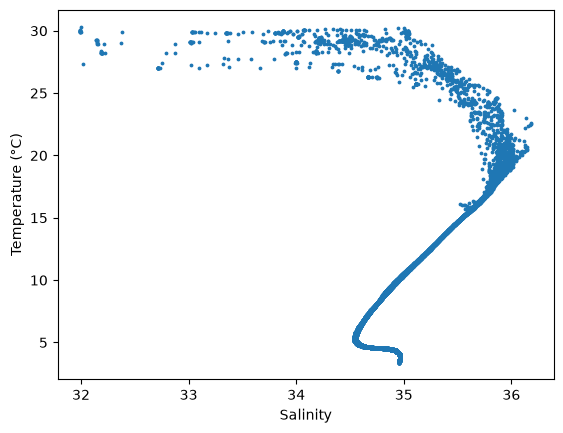

In [83]:
plt.scatter(df["psal"], df["temp"],3)
plt.xlabel("Salinity")
plt.ylabel("Temperature (°C)")

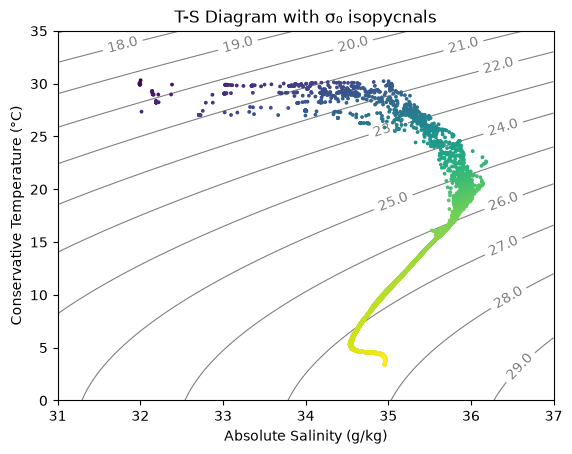

In [84]:
sigma0 = gsw.sigma0(df["psal"], df["temp"])
SA_grid = np.linspace(31, 37, 100)
CT_grid = np.linspace(0, 35, 100)
SA_g, CT_g = np.meshgrid(SA_grid, CT_grid)
sigma_grid = gsw.sigma0(SA_g, CT_g)
fig, ax = plt.subplots()
cs = ax.contour(SA_g, CT_g, sigma_grid, levels=np.arange(17,30), colors='gray', linewidths=0.8)
ax.clabel(cs, fmt='%.1f')
ax.scatter(df["psal"], df["temp"],3, c=sigma0, cmap='viridis', zorder=5)
ax.set_xlabel('Absolute Salinity (g/kg)')
ax.set_ylabel('Conservative Temperature (°C)')
ax.set_title('T-S Diagram with σ₀ isopycnals')
#plt.colorbar(ax.collections[0], label='σ₀ (kg/m³)')
plt.show()


Text(0.5, 0, 'Latitude')

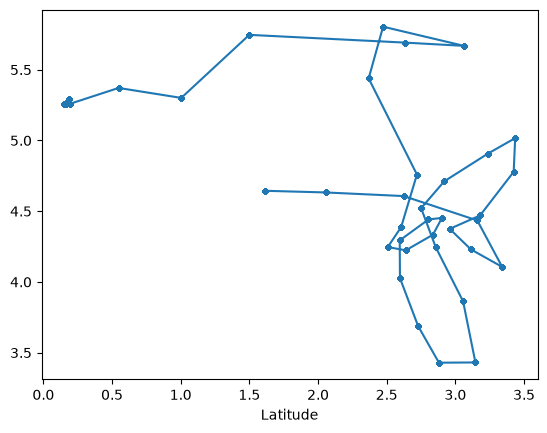

In [85]:
plt.scatter(df["longitude"], df["latitude"],10)
plt.plot(df["longitude"], df["latitude"])
plt.xlabel("Longitude")
plt.xlabel("Latitude")

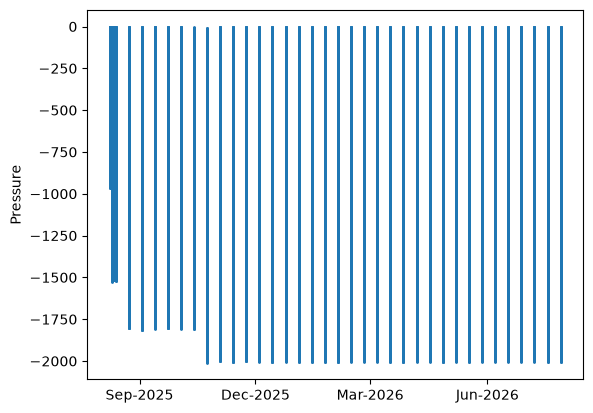

In [87]:
ax = plt.gca()
plt.scatter(df["time"], -df["pres"], 1)
plt.ylabel("Pressure")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))   # or interval=3 for quarterly ticks
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b-%Y"))    # e.g. "Jan-2026"

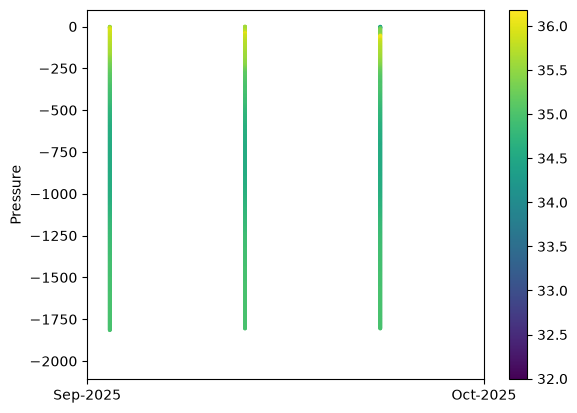

In [94]:
ax = plt.gca()
plt.scatter(df["time"], -df["pres"], 3, df["psal"])
plt.ylabel("Pressure")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))   # or interval=3 for quarterly ticks
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b-%Y"))
plt.xlim(pd.to_datetime("2025-09-01"), pd.to_datetime("2025-10-01"))
plt.colorbar()
#plt.clim(34,36)